# 🌳 Cyberattack Detection: XGBoost Classifier
### Academic Presentation & Walkthrough
---
**Objective:** To detect network intrusions (cyberattacks) using the **NSL-KDD dataset**. 
In this notebook, we will use a **XGBoost Classifier**...

We will walk through step-by-step:
1. Exploring the raw dataset.
2. Cleaning & preprocessing the data (Scaling & One-Hot Encoding).
3. Training the AI.
4. Visualizing exactly how the AI thinks.


### Step 1: Loading the Network Traffic Data
Our first step is to import our libraries and load the raw NSL-KDD text files.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

# NSL-KDD Columns based on the parent project's approach
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'outcome', 'level'
]

# Path to the dataset folder
DATASET_PATH = '../../nsl-kdd/KDDTrain+.txt'
print(f"Loading dataset from {DATASET_PATH}...")

if not os.path.exists(DATASET_PATH):
    print("Warning: File not found. Make sure KDDTrain+.txt is downloaded and placed correctly.")
else:
    df = pd.read_csv(DATASET_PATH, names=columns)
    print(f"Successfully loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")
    display(df.head())

Loading dataset from ../../nsl-kdd/KDDTrain+.txt...
Successfully loaded dataset with 125973 rows and 43 columns.


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


### Step 2: Visualizing the Raw Data (Benign vs Attack)
How much of this traffic is normal, and how much is malicious?

/tmp/ipykernel_11485/3726523453.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=["#2ecc71", "#e74c3c"])


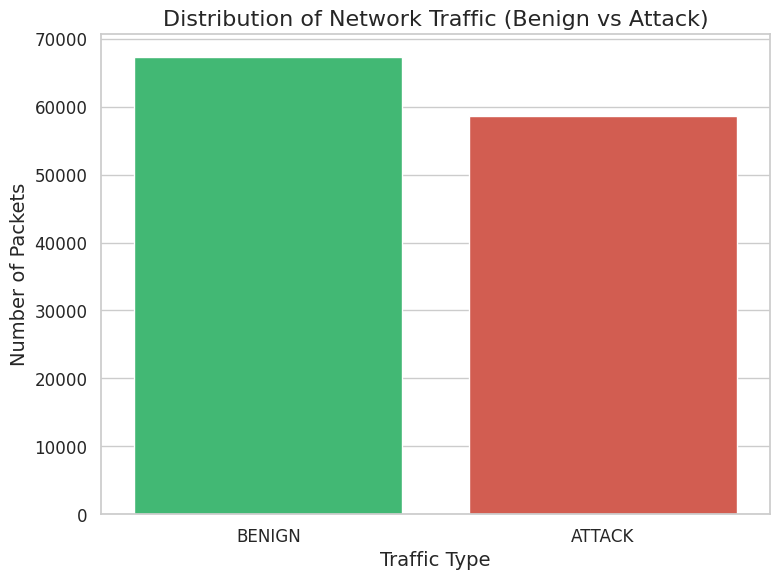

In [2]:
if 'df' in locals():
    # Convert 'normal' to BENIGN and everything else to ATTACK (just like test.ipynb)
    binary_labels = df['outcome'].apply(lambda x: 'BENIGN' if x == 'normal' else 'ATTACK')
    class_counts = binary_labels.value_counts()
    
    plt.figure(figsize=(8, 6))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette=["#2ecc71", "#e74c3c"])
    plt.title('Distribution of Network Traffic (Benign vs Attack)', fontsize=16)
    plt.ylabel('Number of Packets', fontsize=14)
    plt.xlabel('Traffic Type', fontsize=14)
    plt.tight_layout()
    plt.show()

### Step 3: Data Cleaning
We check for missing or mathematically invalid rows and drop the unused 'level' column.

In [3]:
if 'df' in locals():
    initial_count = len(df)
    
    # Drop the 'level' column which is specific to NSL-KDD and not needed
    if 'level' in df.columns:
        df.drop(columns=['level'], inplace=True)
        
    print("Replacing Infinity values with NaNs and dropping them...")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    
    final_count = len(df)
    print(f"Data Cleaned! Dropped {initial_count - final_count} invalid network flows.")
    print(f"Remaining reliable rows for training: {final_count}")

Replacing Infinity values with NaNs and dropping them...
Data Cleaned! Dropped 0 invalid network flows.
Remaining reliable rows for training: 125973


### Step 4: Preprocessing (Scaling & Encoding)
We need to encode the categorical features (`protocol_type`, `service`, `flag`) using `OneHotEncoder`, scale the numbers using `RobustScaler`, and encode our target Label.

In [4]:
from sklearn.preprocessing import LabelEncoder, RobustScaler, OneHotEncoder
import joblib

if 'df' in locals():
    X_raw = df.drop(columns=['outcome'])
    # Recreate the binary target variable for model training
    y = df['outcome'].apply(lambda x: 'BENIGN' if x == 'normal' else 'ATTACK')

    print("Encoding Categorical Features (One-Hot)...")
    cat_cols = ['protocol_type', 'service', 'flag']
    num_cols = [col for col in X_raw.columns if col not in cat_cols]
    
    encoder_features = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded_cats = pd.DataFrame(encoder_features.fit_transform(X_raw[cat_cols]))
    encoded_cats.columns = encoder_features.get_feature_names_out(cat_cols)
    
    X_raw = X_raw.drop(cat_cols, axis=1).reset_index(drop=True)
    X_combined = pd.concat([X_raw, encoded_cats], axis=1)

    print("Scaling Numerical Features (RobustScaler)...")
    scaler = RobustScaler()
    X_combined[num_cols] = scaler.fit_transform(X_combined[num_cols])
    
    X = X_combined
    display(X.head())

    print("\nEncoding string labels into Integers...")
    encoder_label = LabelEncoder()
    y_encoded = encoder_label.fit_transform(y)

    # Save artifacts for the IDS Engine
    joblib.dump(encoder_features, 'encoder.pkl')
    joblib.dump(scaler, 'scaler.pkl')
    joblib.dump(encoder_label, 'label_encoder.pkl')

    classes_df = pd.DataFrame({'Attack Name': encoder_label.classes_, 'Assigned Number': range(len(encoder_label.classes_))})
    display(classes_df)

Encoding Categorical Features (One-Hot)...
Scaling Numerical Features (RobustScaler)...


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.0,1.619565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.369565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,-0.159420,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.681159,15.800388,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.561594,0.813953,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0



Encoding string labels into Integers...


,Attack Name,Assigned Number
0,ATTACK,0
1,BENIGN,1


### Step 5: Training the XGBoost Model
We will slice our dataset into Training Set (80%) and Testing Set (20%).

In [5]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import joblib

if 'df' in locals():
    print("Splitting data into 80% Training and 20% Testing sets...")
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

    print('Initializing the XGBoost AI...')
model = XGBClassifier(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)

print('Training the AI on the Training Set...')
model.fit(X_train, y_train)

print('Saving the model...')
joblib.dump(model, 'xgb_model.pkl')

print('Training Complete!')

Splitting data into 80% Training and 20% Testing sets...
Initializing the XGBoost AI...
Training the AI on the Training Set...
Saving the model...
Training Complete!


### Step 6: Evaluation & Testing
Let's bring in the Testing Set that the AI has never seen before.

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

if 'df' in locals():
    print("AI is predicting the labels for the totally unseen Test Set...")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n OVERALL ACCURACY: {accuracy * 100:.2f}%")

    y_test_decoded = encoder_label.inverse_transform(y_test)
    y_pred_decoded = encoder_label.inverse_transform(y_pred)

    print("\n Detailed Classification Report:")
    print(classification_report(y_test_decoded, y_pred_decoded))

AI is predicting the labels for the totally unseen Test Set...

 OVERALL ACCURACY: 99.90%

 Detailed Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     11726
      BENIGN       1.00      1.00      1.00     13469

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



### Step 7: The Confusion Matrix Heatmap
A visual Confusion Matrix Heatmap is the best way to present this.

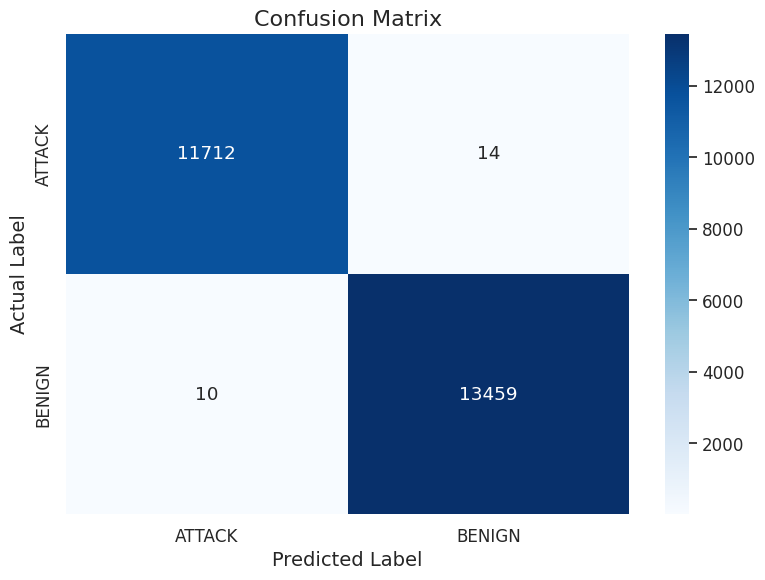

In [7]:
if 'df' in locals():
    cm = confusion_matrix(y_test_decoded, y_pred_decoded, labels=encoder_label.classes_)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder_label.classes_, yticklabels=encoder_label.classes_)
    plt.title('Confusion Matrix', fontsize=16)
    plt.ylabel('Actual Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.tight_layout()
    plt.show()